In [8]:
!pip install streamlit
!pip install transformers

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install praat-parselmouth
import parselmouth

#### Step 1 Load The Data.

In [10]:
def load_and_clean_data(file_path):
    df = pd.read_csv(file_path)
    return df

df = load_and_clean_data('/content/vocal_gender_features_new.csv')
print(df.head())

   mean_spectral_centroid  std_spectral_centroid  mean_spectral_bandwidth  \
0             2247.331739            1158.537748              1870.415462   
1             1790.719889             996.554825              1757.898617   
2             1977.923363            1010.148667              1747.099555   
3             2037.765550            1311.440630              1745.224852   
4             1739.383829            1092.623322              1623.135563   

   std_spectral_bandwidth  mean_spectral_contrast  mean_spectral_flatness  \
0              370.405241               21.440710                0.036879   
1              410.710318               21.513383                0.018936   
2              461.458379               20.476283                0.032616   
3              419.056484               19.516014                0.028482   
4              450.088465               20.260620                0.025737   

   mean_spectral_rolloff  zero_crossing_rate  rms_energy  mean_pitch  ... 

####1. Columns + Data Types + Missing Values summary

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16148 entries, 0 to 16147
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean_spectral_centroid   16148 non-null  float64
 1   std_spectral_centroid    16148 non-null  float64
 2   mean_spectral_bandwidth  16148 non-null  float64
 3   std_spectral_bandwidth   16148 non-null  float64
 4   mean_spectral_contrast   16148 non-null  float64
 5   mean_spectral_flatness   16148 non-null  float64
 6   mean_spectral_rolloff    16148 non-null  float64
 7   zero_crossing_rate       16148 non-null  float64
 8   rms_energy               16148 non-null  float64
 9   mean_pitch               16148 non-null  float64
 10  min_pitch                16148 non-null  float64
 11  max_pitch                16148 non-null  float64
 12  std_pitch                16148 non-null  float64
 13  spectral_skew            16148 non-null  float64
 14  spectral_kurtosis     

###2. Numeric Features

In [12]:
df.describe()

,mean_spectral_centroid,std_spectral_centroid,mean_spectral_bandwidth,std_spectral_bandwidth,mean_spectral_contrast,mean_spectral_flatness,mean_spectral_rolloff,zero_crossing_rate,rms_energy,mean_pitch,...,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,label
count,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,...,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000
mean,1709.269730,1027.564673,1584.195931,432.492328,20.395652,0.023086,3281.808257,0.118088,0.084759,1461.624198,...,13.537739,-0.533815,12.515116,-8.933890,10.982858,0.880024,9.721608,-6.711788,9.536517,0.642804
std,315.558063,286.303662,126.360465,78.723202,1.628596,0.010027,526.824341,0.037707,0.022814,287.763342,...,2.438230,5.593673,2.354020,5.315098,1.886158,4.314862,1.794407,4.069641,1.574890,0.479188
min,719.559285,194.998983,1106.939002,199.321584,15.154801,0.001816,1310.661765,0.027727,0.022425,359.391170,...,5.826506,-20.188465,5.459179,-26.082537,5.594748,-13.585977,4.378153,-26.402317,4.686154,0.000000
25%,1475.078509,829.195585,1503.301521,379.552391,19.775875,0.015567,2911.427574,0.089729,0.067508,1279.141250,...,11.861280,-4.521667,10.753869,-12.666048,9.641137,-2.050272,8.455685,-9.676477,8.432545,0.000000
50%,1703.038854,1048.531356,1583.959951,423.121818,20.759579,0.021737,3293.459741,0.116623,0.083121,1484.461250,...,13.306489,-0.625990,12.279825,-8.732289,10.796652,0.949182,9.595896,-6.598702,9.433592,1.000000
75%,1921.202685,1233.451527,1665.806788,477.631817,21.516436,0.029175,3637.773811,0.144095,0.100465,1662.883350,...,15.044193,3.136063,14.099204,-5.328175,12.153640,3.896141,10.863349,-3.575793,10.508087,1.000000
max,3059.390150,1912.173446,2046.070801,724.361505,24.907725,0.072172,5451.099537,0.270710,0.187577,2454.724000,...,26.693924,19.610289,22.717190,6.013963,19.685654,16.436730,17.380630,6.187790,17.941544,1.000000


###3. Missing values

In [13]:
df.isnull().sum()

,0
mean_spectral_centroid,0
std_spectral_centroid,0
mean_spectral_bandwidth,0
std_spectral_bandwidth,0
mean_spectral_contrast,0
mean_spectral_flatness,0
mean_spectral_rolloff,0
zero_crossing_rate,0
rms_energy,0
mean_pitch,0


#### 4. Shape of dataset

In [14]:
df.shape

(16148, 44)

### 5. Duplicate Values

In [15]:
df.duplicated().sum()

np.int64(1078)

In [16]:
## Total Missing Value

In [17]:
print("\nTotal Missing Values:", df.isnull().sum().sum())


Total Missing Values: 0


In [18]:
## Label Balance ( Male & Female)

In [19]:
print("\n Label Balance (male=1, female=0):")
print(df['label'].value_counts())


 Label Balance (male=1, female=0):
label
1    10380
0     5768
Name: count, dtype: int64


In [20]:
## Percent Distribution

In [21]:
print("\nLabel Distribution (%):")
print(df['label'].value_counts(normalize=True) * 100)


Label Distribution (%):
label
1    64.280406
0    35.719594
Name: proportion, dtype: float64


In [22]:
## Number of Rows & Columns

In [23]:
print("\n Dataset Shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


 Dataset Shape:
Rows: 16148
Columns: 44


In [24]:
df['label'].value_counts()

,count
label,
1,10380
0,5768


### Step 2 Cleaned the Data Using The Different Method

In [25]:
##Missing Value Handling

In [26]:
print("Missing values in each column:")
print(df.isnull().sum())

df_cleaned = df.copy()

df_cleaned = df_cleaned.fillna(df_cleaned.mean())

Missing values in each column:
mean_spectral_centroid     0
std_spectral_centroid      0
mean_spectral_bandwidth    0
std_spectral_bandwidth     0
mean_spectral_contrast     0
mean_spectral_flatness     0
mean_spectral_rolloff      0
zero_crossing_rate         0
rms_energy                 0
mean_pitch                 0
min_pitch                  0
max_pitch                  0
std_pitch                  0
spectral_skew              0
spectral_kurtosis          0
energy_entropy             0
log_energy                 0
mfcc_1_mean                0
mfcc_1_std                 0
mfcc_2_mean                0
mfcc_2_std                 0
mfcc_3_mean                0
mfcc_3_std                 0
mfcc_4_mean                0
mfcc_4_std                 0
mfcc_5_mean                0
mfcc_5_std                 0
mfcc_6_mean                0
mfcc_6_std                 0
mfcc_7_mean                0
mfcc_7_std                 0
mfcc_8_mean                0
mfcc_8_std                 0
mfcc_9_mean 

In [27]:
## Duplicate Value Remove

In [28]:
duplicate_count = df_cleaned.duplicated().sum()
print("Duplicate Rows:", duplicate_count)

df_cleaned = df_cleaned.drop_duplicates()

print("Shape after removing duplicates:", df_cleaned.shape)

Duplicate Rows: 1078
Shape after removing duplicates: (15070, 44)


In [29]:
##Outliner Detection

In [30]:
from scipy import stats

df_out = df_cleaned.copy()

numeric_cols = df_out.select_dtypes(include=['float64','int64']).columns

z_scores = np.abs(stats.zscore(df_out[numeric_cols]))

print("Z-score shape:", z_scores.shape)

outlier_rows = np.where(z_scores > 3)[0]

print("Number of outlier rows detected:", len(outlier_rows))


Z-score shape: (15070, 44)
Number of outlier rows detected: 2949


In [31]:
df_out = df_out[(z_scores < 3).all(axis=1)]
print("Shape after removing outliers:", df_out.shape)

Shape after removing outliers: (12831, 44)


In [32]:
df_out.to_csv("processed_features.csv", index=False)
print("Cleaned file saved as processed_features.csv")

Cleaned file saved as processed_features.csv


### Data Preparation

In [33]:
## 1. Use the provided dataset containing extracted voice features.

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
df = pd.read_csv("processed_features.csv")

In [36]:
print("Dataset Loaded Successfully!")
print(df.head())
print("\nShape of dataset:", df.shape)

Dataset Loaded Successfully!
   mean_spectral_centroid  std_spectral_centroid  mean_spectral_bandwidth  \
0             1790.719889             996.554825              1757.898617   
1             1977.923363            1010.148667              1747.099555   
2             2037.765550            1311.440630              1745.224852   
3             1739.383829            1092.623322              1623.135563   
4             2012.022171            1248.922879              1725.005365   

   std_spectral_bandwidth  mean_spectral_contrast  mean_spectral_flatness  \
0              410.710318               21.513383                0.018936   
1              461.458379               20.476283                0.032616   
2              419.056484               19.516014                0.028482   
3              450.088465               20.260620                0.025737   
4              459.774696               21.442285                0.022706   

   mean_spectral_rolloff  zero_crossing_rate 

In [37]:
X = df.drop("label", axis=1)
y = df["label"]

In [38]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

In [39]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (8981, 43)
Shape of X_test: (1925, 43)
Shape of y_train: (8981,)
Shape of y_test: (1925,)


In [40]:
## 2. Split the dataset into training, validation, and test sets.

In [41]:
print("Train set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (8981, 43) (8981,)
Validation set: (1925, 43) (1925,)
Test set: (1925, 43) (1925,)


### Data Cleaning and Preprocessing

In [42]:
## 1. Handle missing or inconsistent data.

In [43]:
from sklearn.impute import SimpleImputer

In [44]:
df.columns = df.columns.str.strip().str.lower()

In [45]:
# Identify numeric & categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [46]:
num_imputer = SimpleImputer(strategy="median")
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

In [47]:
print("Missing values handled successfully!")
print(df.isna().sum())

Missing values handled successfully!
mean_spectral_centroid     0
std_spectral_centroid      0
mean_spectral_bandwidth    0
std_spectral_bandwidth     0
mean_spectral_contrast     0
mean_spectral_flatness     0
mean_spectral_rolloff      0
zero_crossing_rate         0
rms_energy                 0
mean_pitch                 0
min_pitch                  0
max_pitch                  0
std_pitch                  0
spectral_skew              0
spectral_kurtosis          0
energy_entropy             0
log_energy                 0
mfcc_1_mean                0
mfcc_1_std                 0
mfcc_2_mean                0
mfcc_2_std                 0
mfcc_3_mean                0
mfcc_3_std                 0
mfcc_4_mean                0
mfcc_4_std                 0
mfcc_5_mean                0
mfcc_5_std                 0
mfcc_6_mean                0
mfcc_6_std                 0
mfcc_7_mean                0
mfcc_7_std                 0
mfcc_8_mean                0
mfcc_8_std                 0
mfcc_9

In [48]:
## 2. Normalize numerical features for consistency.

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

In [50]:
X = df.drop("label", axis=1)
y = df["label"]

In [51]:
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns

In [52]:
scaler = StandardScaler()

X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("Normalization completed!")
print(X_scaled.head())

Normalization completed!
   mean_spectral_centroid  std_spectral_centroid  mean_spectral_bandwidth  \
0                0.286890              -0.118184                 1.398943   
1                0.904177              -0.068228                 1.311987   
2                1.101501               1.038994                 1.296891   
3                0.117614               0.234860                 0.313799   
4                1.016614               0.809247                 1.134079   

   std_spectral_bandwidth  mean_spectral_contrast  mean_spectral_flatness  \
0               -0.250542                0.719624               -0.449451   
1                0.436655                0.088387                1.017528   
2               -0.137524               -0.496086                0.574194   
3                0.282691               -0.042878                0.279915   
4                0.413855                0.676350               -0.045149   

   mean_spectral_rolloff  zero_crossing_rate  rms

### Exploratory Data Analysis (EDA)

In [53]:
## 1. Visualize feature distributions and correlations

In [54]:
## a. Feature distributions

In [55]:
## Histograms

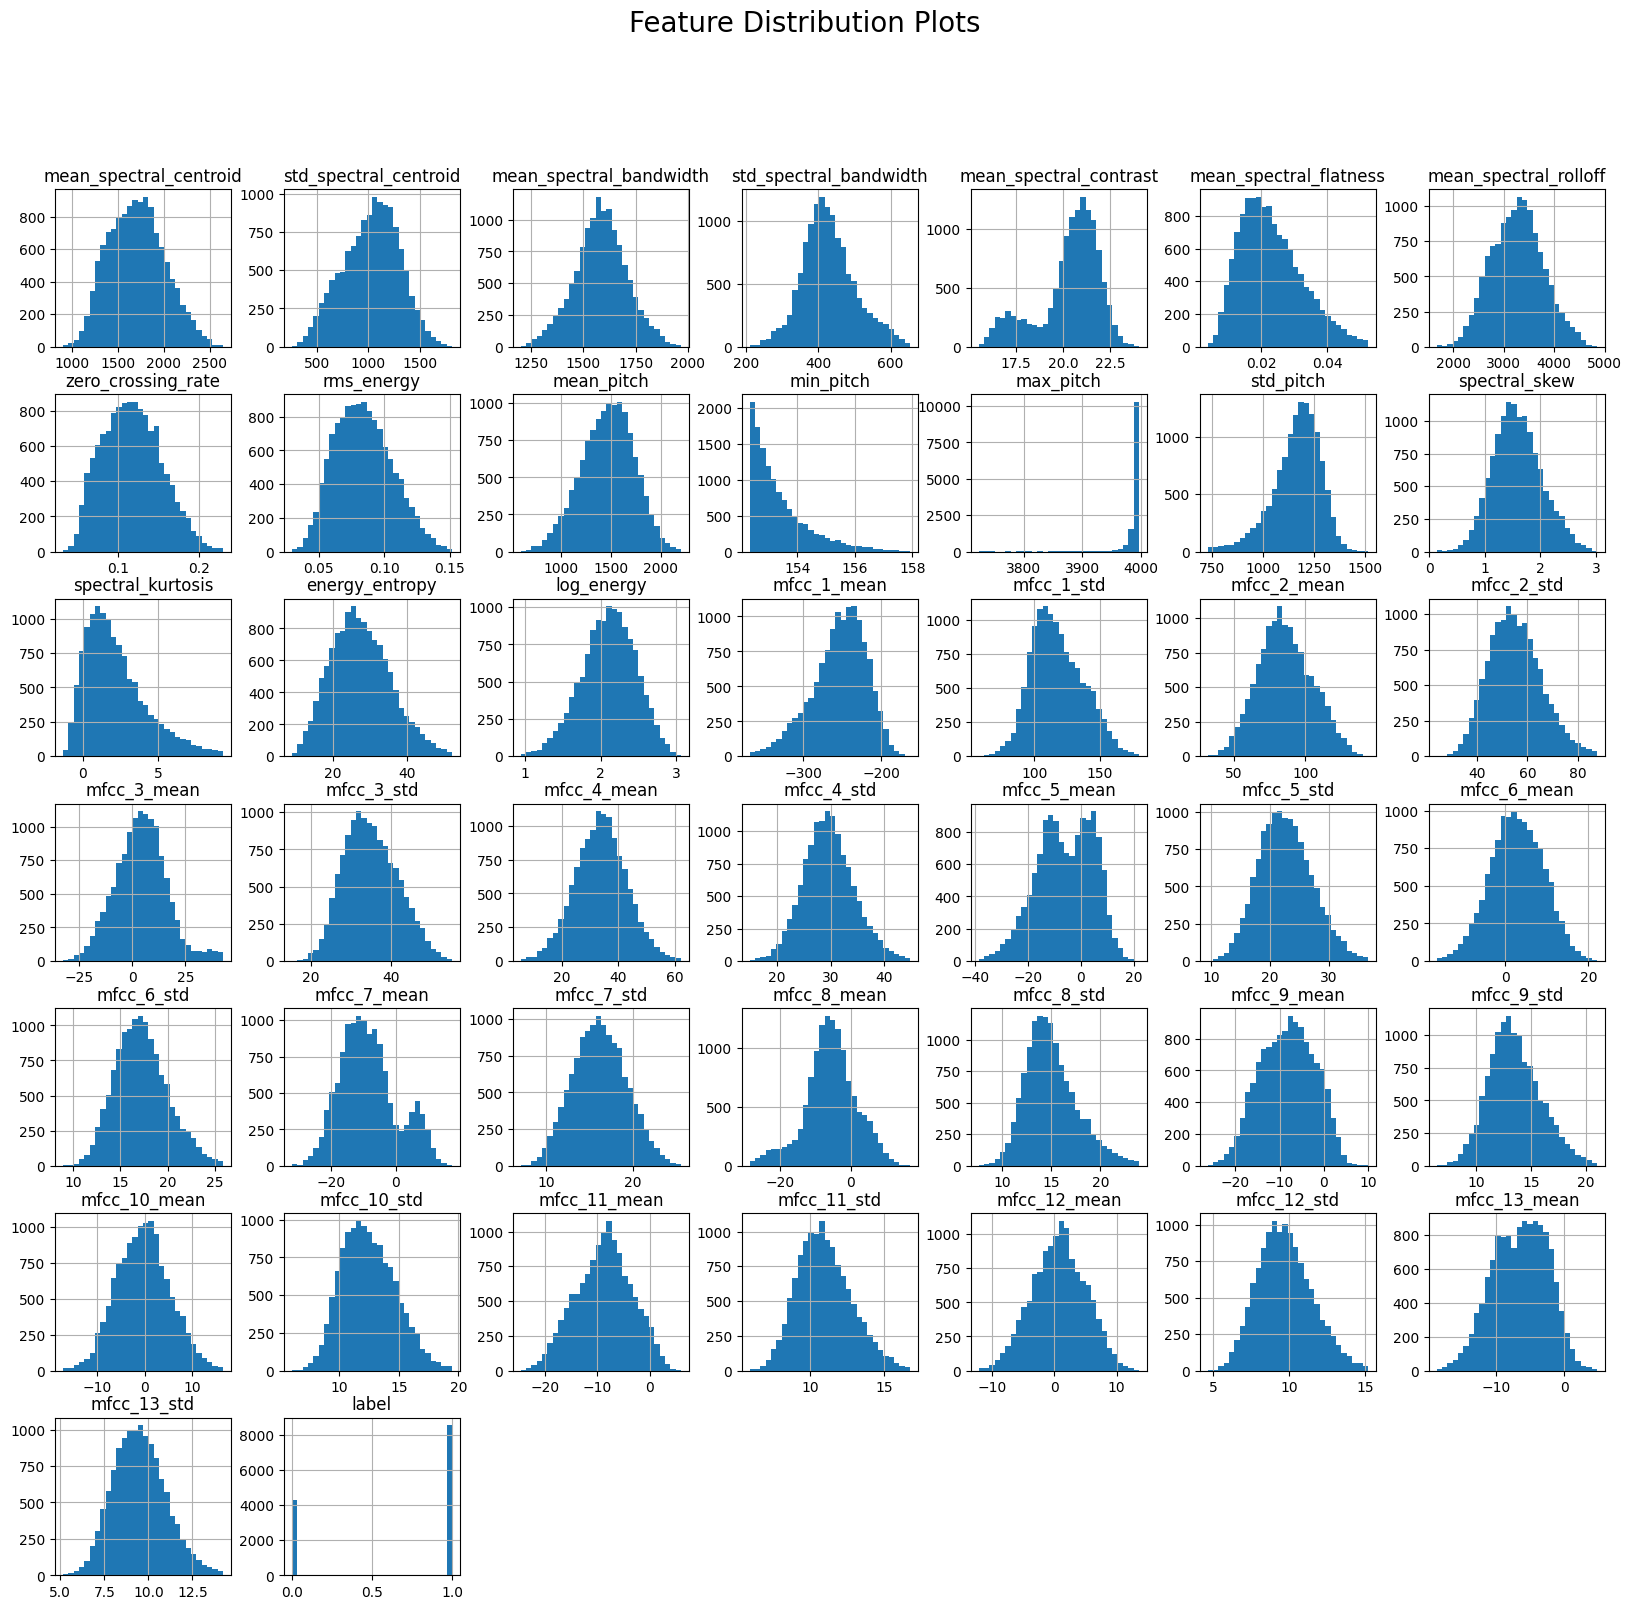

In [56]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[num_cols].hist(bins=30, figsize=(20, 18))
plt.suptitle("Feature Distribution Plots", fontsize=20)
plt.show()

In [57]:
## KDE Plot (Smooth Curve)

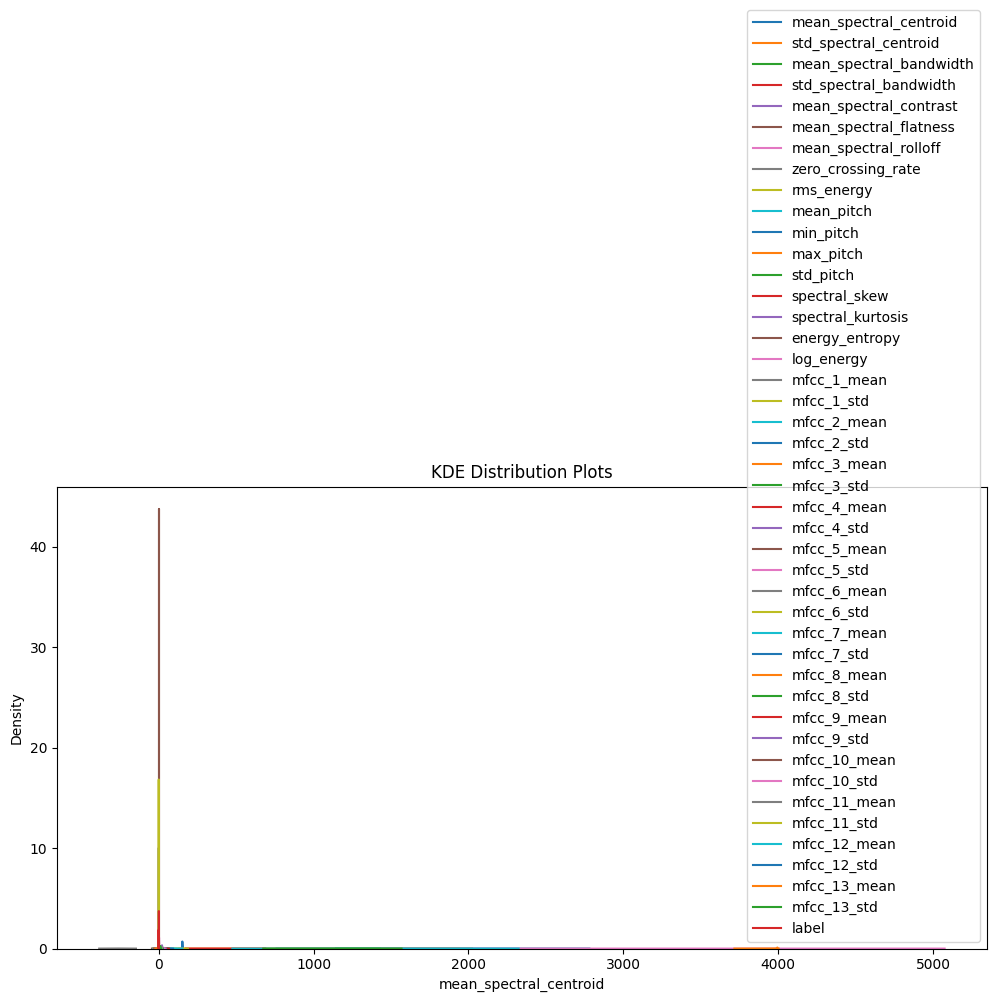

In [58]:
plt.figure(figsize=(12, 6))

for col in num_cols:
    sns.kdeplot(df[col], label=col)

plt.title("KDE Distribution Plots")
plt.legend()
plt.show()

In [59]:
## b. Correlation heatmap

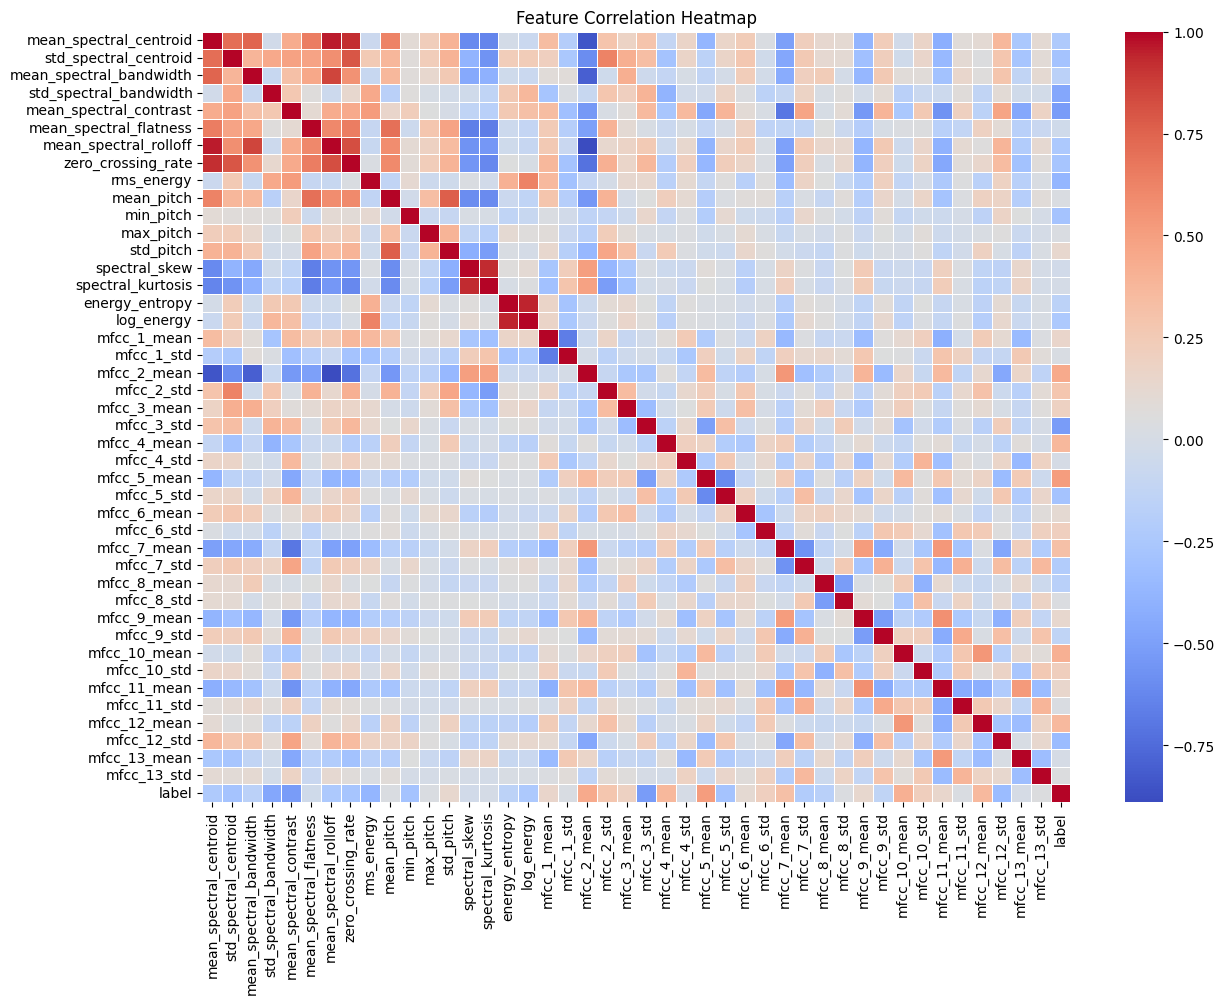

In [60]:
corr = df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [61]:
target = "label"
corr_target = corr[target].sort_values(ascending=False)

print("Top correlated features with target:")
print(corr_target.head(10))

Top correlated features with target:
label           1.000000
mfcc_5_mean     0.506592
mfcc_2_mean     0.444999
mfcc_10_mean    0.414444
mfcc_4_mean     0.368358
mfcc_12_mean    0.364150
mfcc_7_mean     0.317468
mfcc_2_std      0.279193
mfcc_10_std     0.214727
mfcc_6_std      0.209420
Name: label, dtype: float64


In [62]:
## 2. Analyze patterns in spectral and pitch-related features

In [63]:
## A. Visualizations Spectrals Feature

In [64]:
spectral_cols = []
keywords = ["mfcc", "centroid", "bandwidth", "rolloff", "flux"]

for col in df.columns:
    if any(k in col for k in keywords):
        spectral_cols.append(col)

spectral_cols

['mean_spectral_centroid',
 'std_spectral_centroid',
 'mean_spectral_bandwidth',
 'std_spectral_bandwidth',
 'mean_spectral_rolloff',
 'mfcc_1_mean',
 'mfcc_1_std',
 'mfcc_2_mean',
 'mfcc_2_std',
 'mfcc_3_mean',
 'mfcc_3_std',
 'mfcc_4_mean',
 'mfcc_4_std',
 'mfcc_5_mean',
 'mfcc_5_std',
 'mfcc_6_mean',
 'mfcc_6_std',
 'mfcc_7_mean',
 'mfcc_7_std',
 'mfcc_8_mean',
 'mfcc_8_std',
 'mfcc_9_mean',
 'mfcc_9_std',
 'mfcc_10_mean',
 'mfcc_10_std',
 'mfcc_11_mean',
 'mfcc_11_std',
 'mfcc_12_mean',
 'mfcc_12_std',
 'mfcc_13_mean',
 'mfcc_13_std']

<Figure size 1600x1500 with 0 Axes>

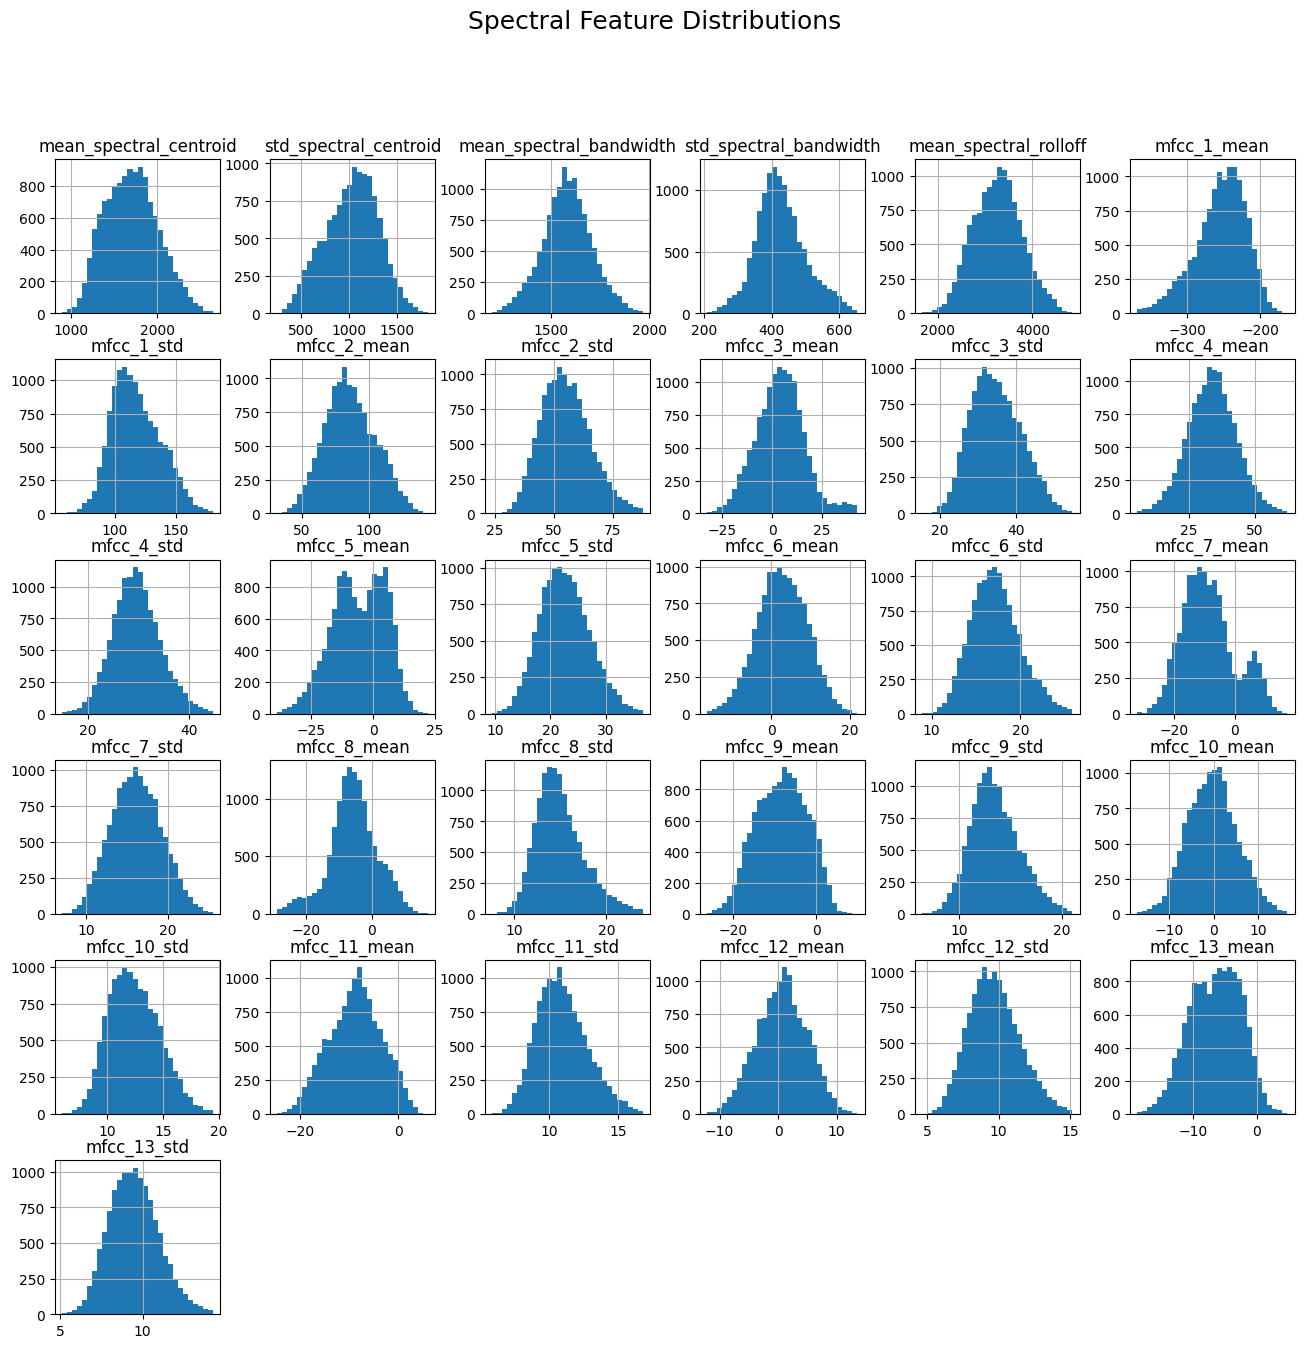

In [65]:
plt.figure(figsize=(16, 15))
df[spectral_cols].hist(bins=30, figsize=(16, 15))
plt.suptitle("Spectral Feature Distributions", fontsize=18)
plt.show()

In [66]:
## Violin Plots

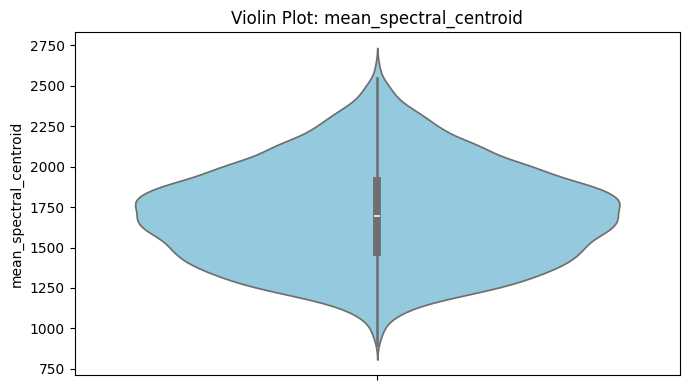

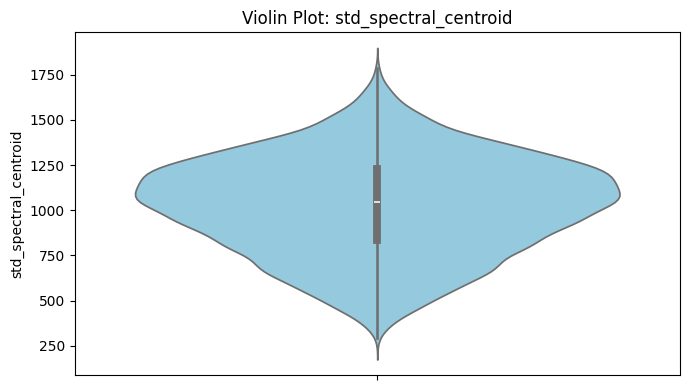

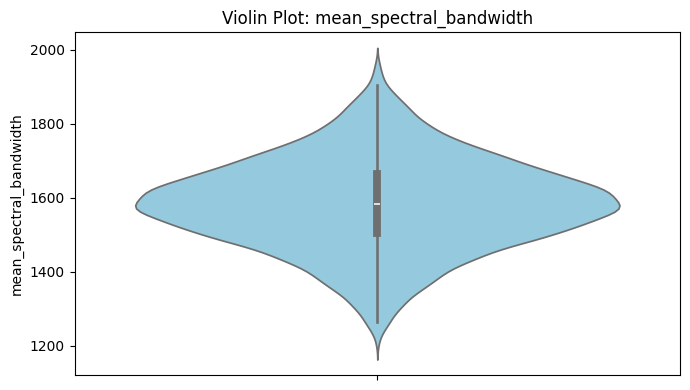

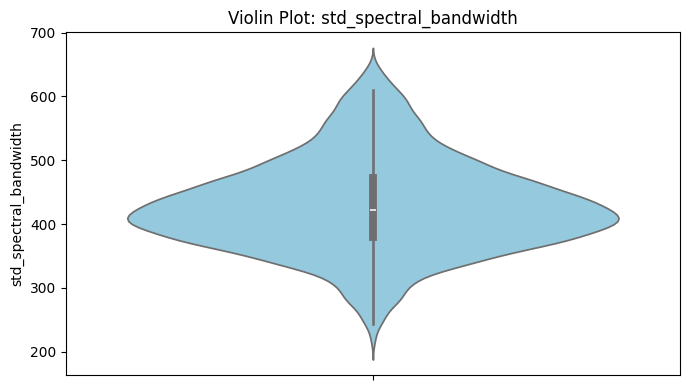

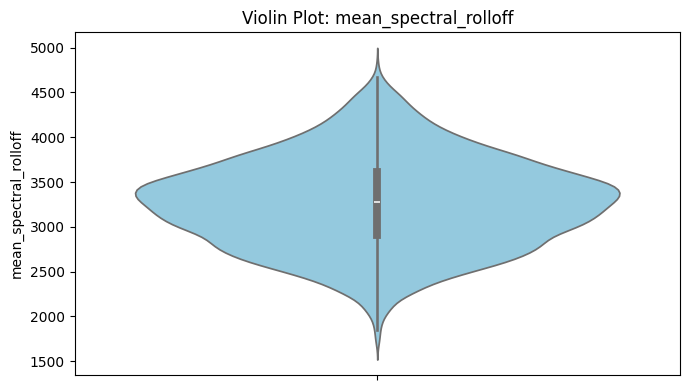

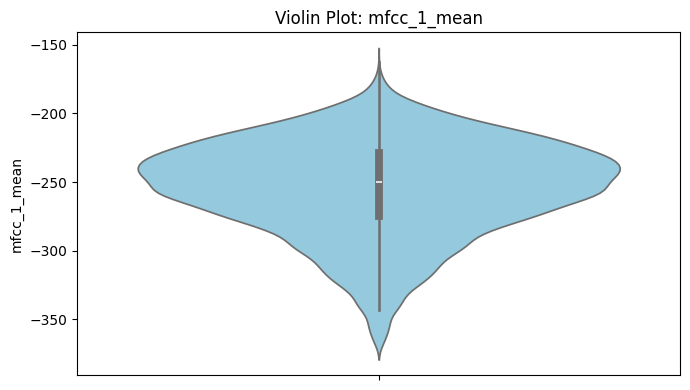

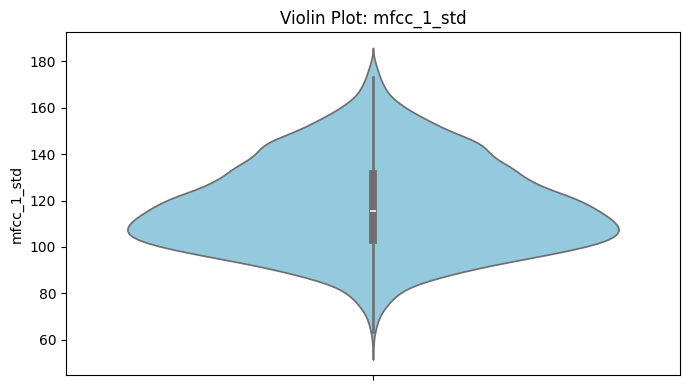

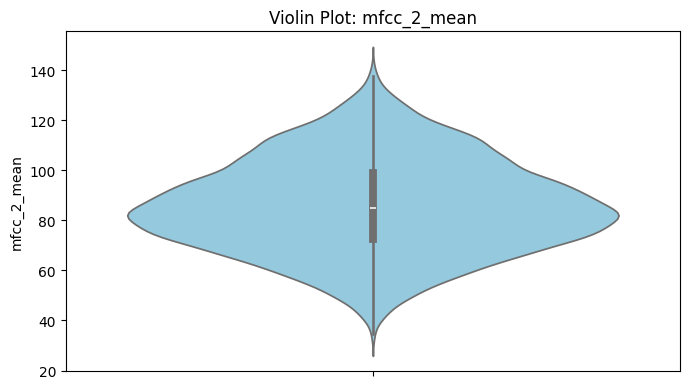

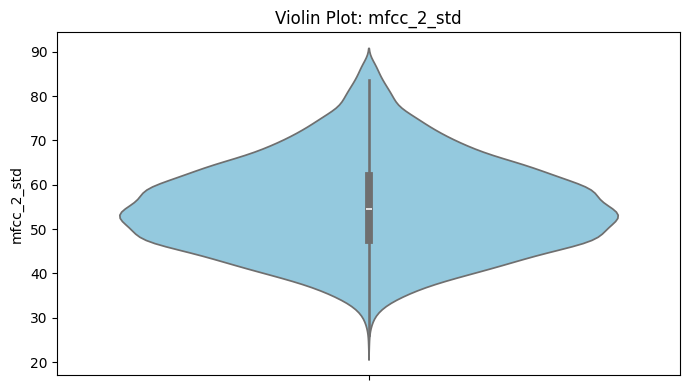

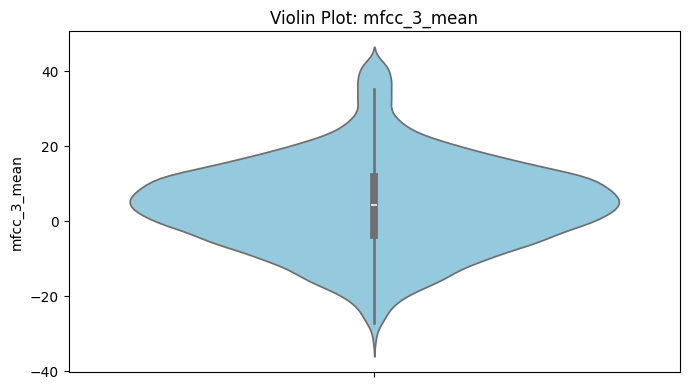

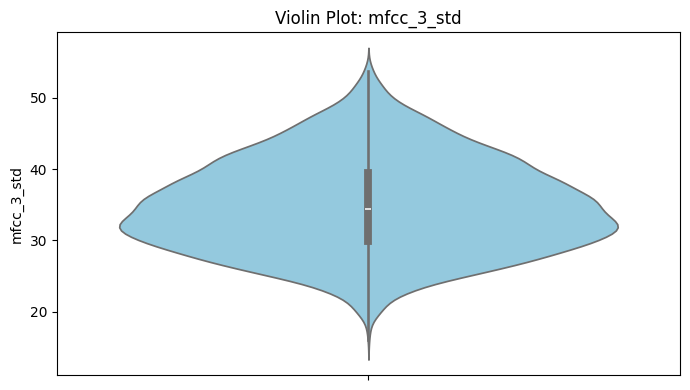

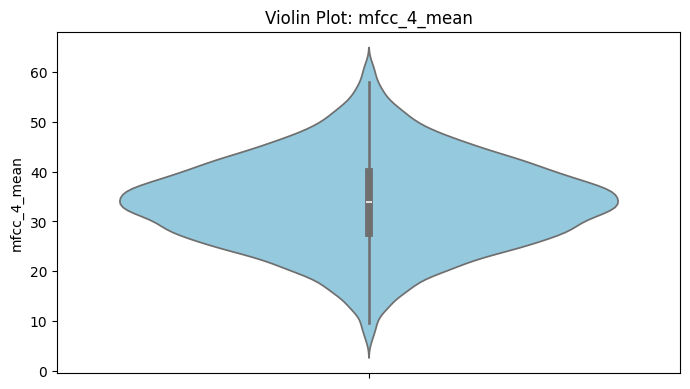

In [67]:
for col in spectral_cols[:12]:
    plt.figure(figsize=(7,4))
    sns.violinplot(y=df[col], color="skyblue")
    plt.title(f"Violin Plot: {col}")
    plt.tight_layout()
    plt.show()

In [68]:
## Box Plots

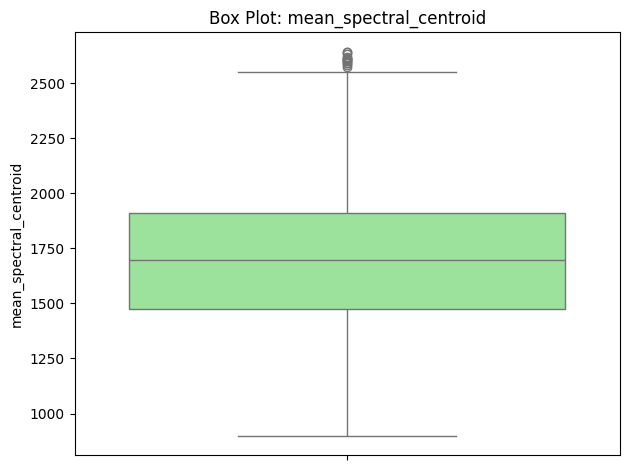

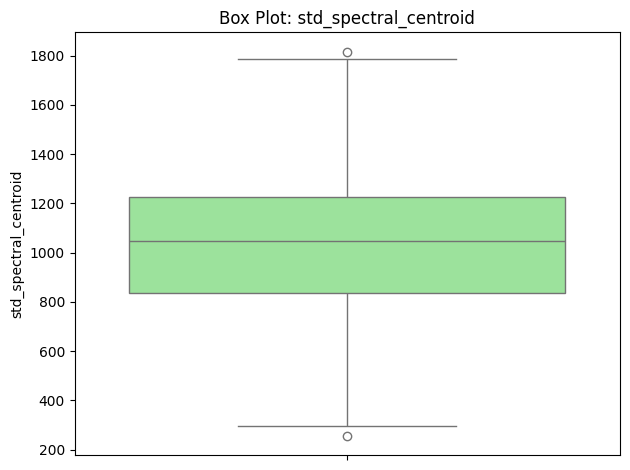

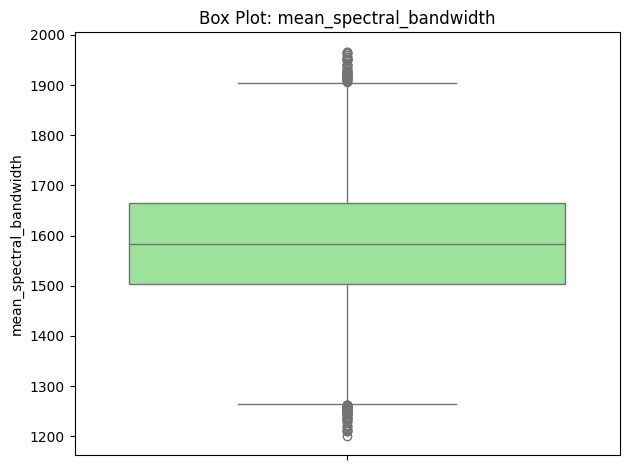

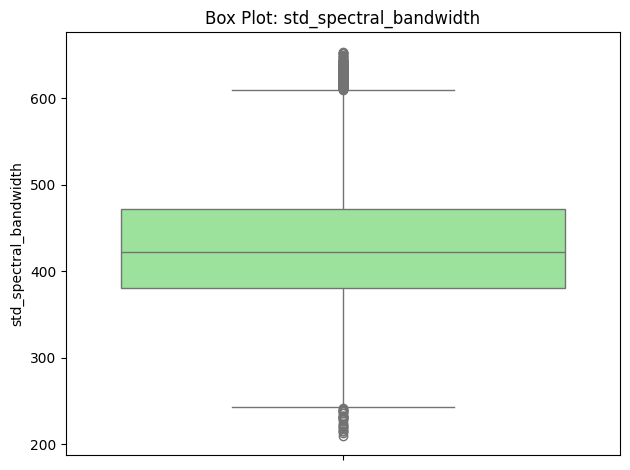

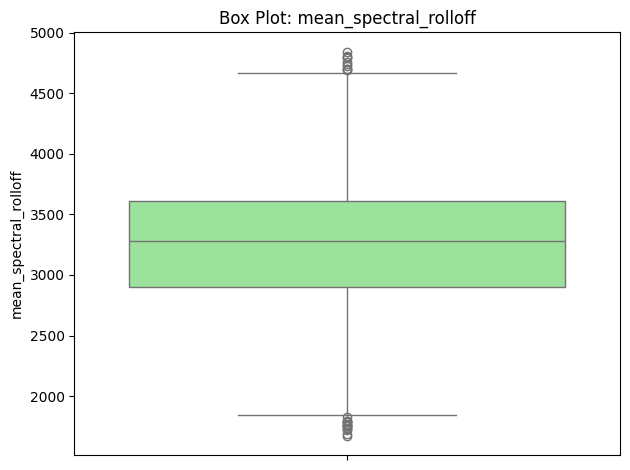

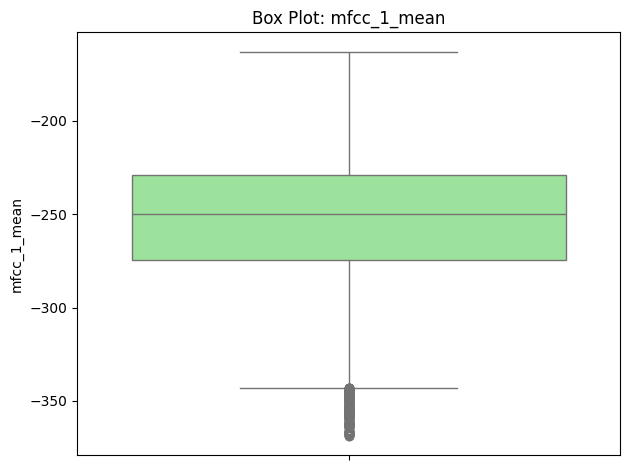

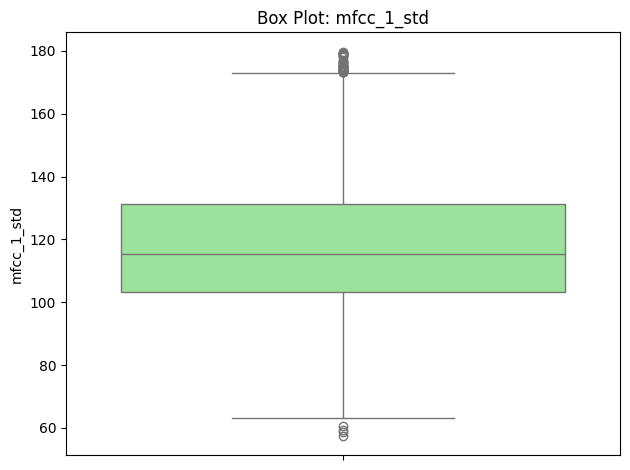

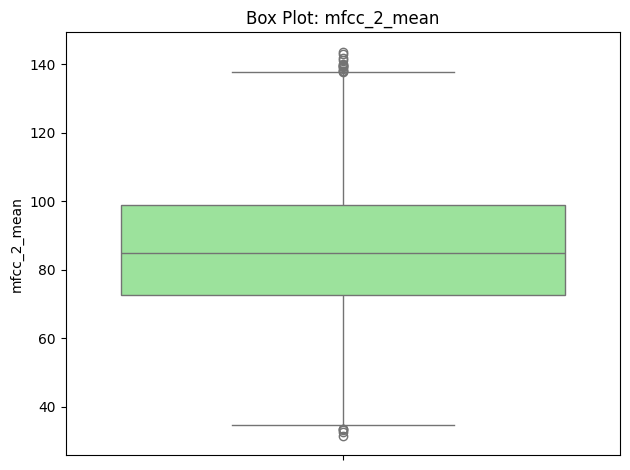

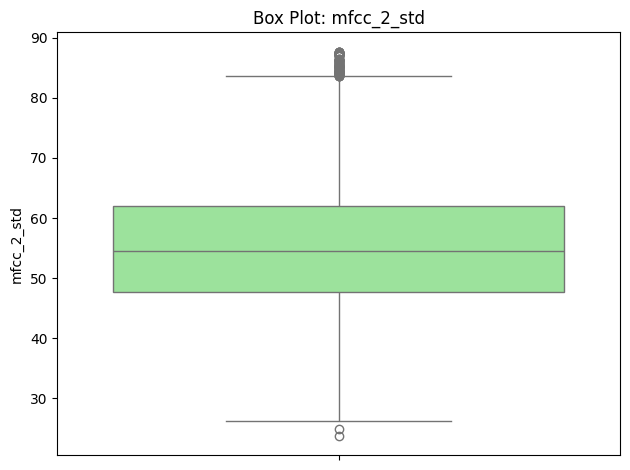

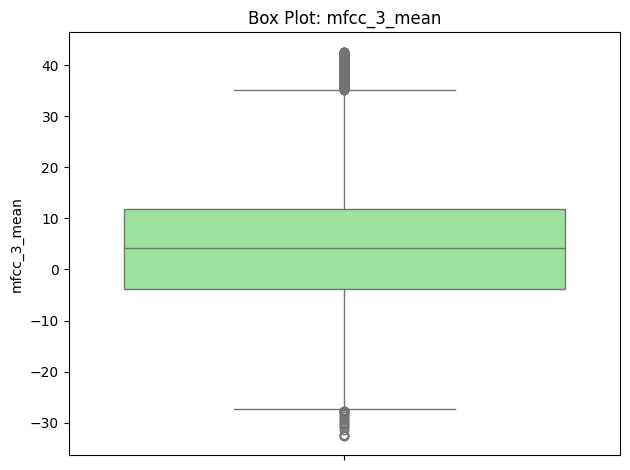

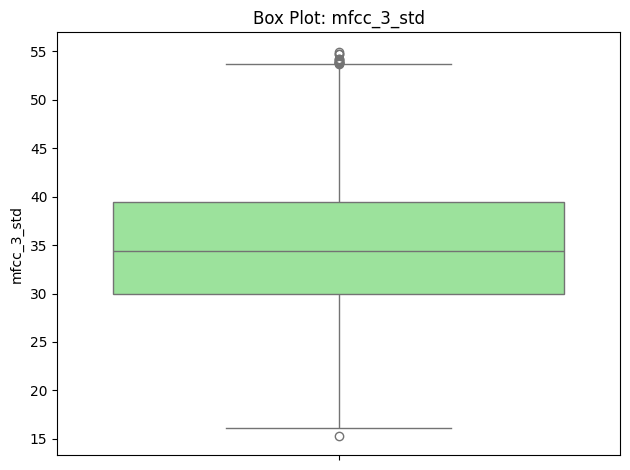

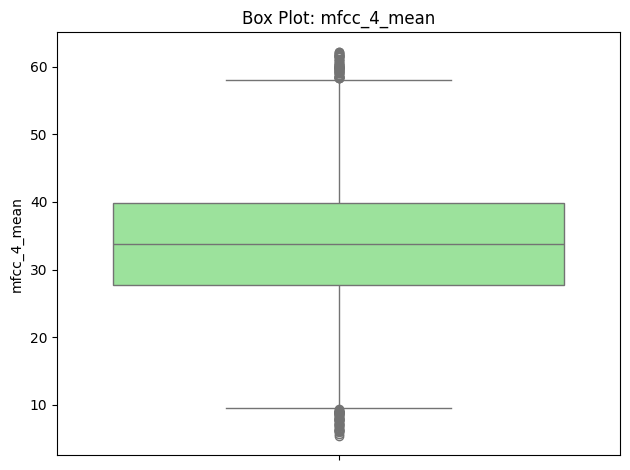

In [69]:
for col in spectral_cols[:12]:
    sns.boxplot(y=df[col], color="lightgreen")
    plt.title(f"Box Plot: {col}")
    plt.tight_layout()
    plt.show()

In [70]:
## B. Pitch Features

In [75]:
import zipfile
ZIP_NAME = "human voice clustering.zip"
AUDIO_EXTS = (".wav", ".flac", ".mp3", ".m4a", ".ogg")

found = []
if os.path.exists(ZIP_NAME):
    with zipfile.ZipFile(ZIP_NAME, 'r') as z:
        for n in z.namelist():
            if n.lower().endswith(AUDIO_EXTS):
                found.append(n)
if len(found)==0:
    print("Zip audio file (.wav/.mp3/.flac/.m4a/.ogg)")
else:
    print(f"Zip  {len(found)} audio files")
    for f in found:
        print(" -", f)

Zip audio file (.wav/.mp3/.flac/.m4a/.ogg)


In [76]:
import soundfile as sf

sr = 16000
duration = 2.0   # seconds
t = np.linspace(0, duration, int(sr*duration), endpoint=False)
freq = 220.0     # A3 tone (220 Hz) - human-like pitch
y = 0.3 * np.sin(2*np.pi*freq*t)   # amplitude 0.3

out_path = "test_tone.wav"
sf.write(out_path, y, sr)
print("Created test audio:", out_path)


Created test audio: test_tone.wav


In [77]:
## FO (Pitch) Graphs

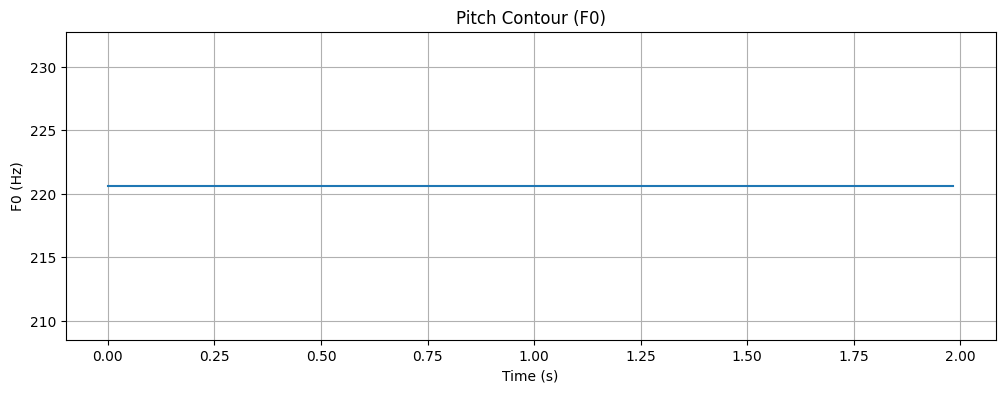

In [78]:
f0, voiced_flag, voiced_prob = librosa.pyin(
    y,
    fmin=50,
    fmax=500,
    sr=sr
)

times = librosa.times_like(f0, sr=sr)

plt.figure(figsize=(12,4))
plt.plot(times, f0)
plt.title("Pitch Contour (F0)")
plt.xlabel("Time (s)")
plt.ylabel("F0 (Hz)")
plt.grid()
plt.show()

In [79]:
## Voicing Probability Graph

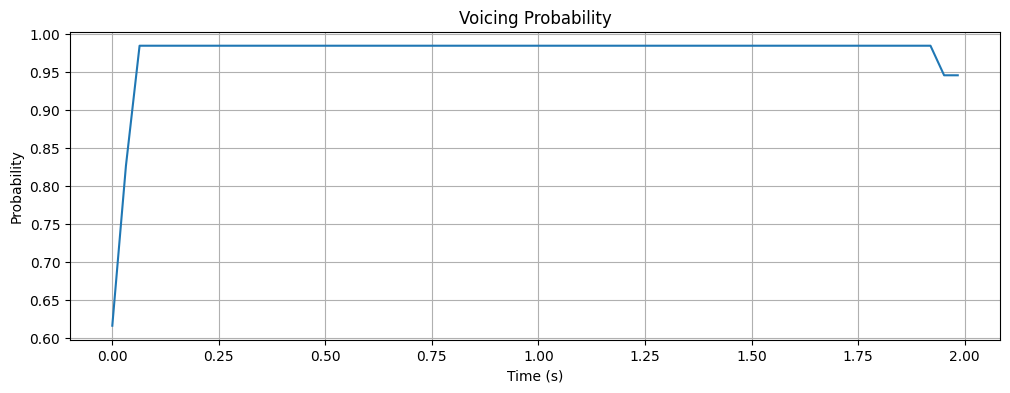

In [80]:
plt.figure(figsize=(12,4))
plt.plot(times, voiced_prob)
plt.title("Voicing Probability")
plt.xlabel("Time (s)")
plt.ylabel("Probability")
plt.grid()
plt.show()

In [81]:
## Pitch Distribution Graph

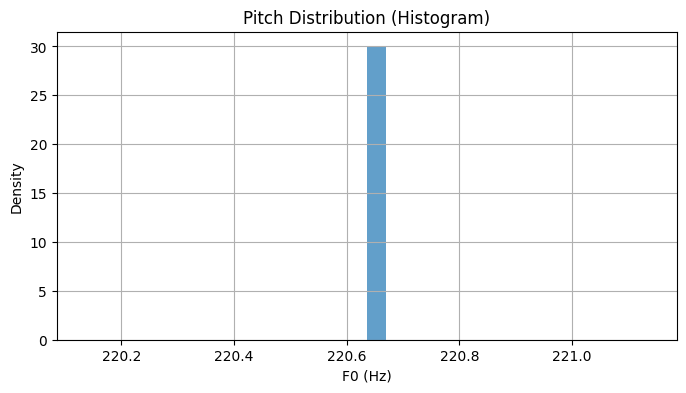

In [82]:
voiced_f0 = f0[~np.isnan(f0)]

plt.figure(figsize=(8,4))
plt.hist(voiced_f0, bins=30, density=True, alpha=0.7)
plt.title("Pitch Distribution (Histogram)")
plt.xlabel("F0 (Hz)")
plt.ylabel("Density")
plt.grid()
plt.show()

In [83]:
## Jitter & Shimmer (Parselmouth)

In [84]:
!pip install praat-parselmouth

import parselmouth
print("Praat Parselmouth installed successfully!")

Praat Parselmouth installed successfully!


In [85]:
import parselmouth
from parselmouth.praat import call

In [86]:
audio_path = "/content/test_tone.wav"
snd = parselmouth.Sound(audio_path)
pp = call(snd, "To PointProcess (periodic, cc)", 75, 500)

In [87]:
tests = {
    "6 args":  [0,0,0.0001,0.02,1.3,0.0001],
    "7 args":  [0,0,0.0001,0.02,1.3,0.0001,0.02],
    "8 args":  [0,0,0.0001,0.02,1.3,0.0001,0.02,1.6]
}

for name, args in tests.items():
    try:
        val = call([snd, pp], "Get shimmer (local)", *args)
        print(f"SUCCESS → {name} works, value={val}")
    except Exception as e:
        print(f"FAIL → {name} → {str(e)[:80]}")

SUCCESS → 6 args works, value=nan
FAIL → 7 args → Command requires only 6 arguments, not the 7 given.
FAIL → 8 args → Command requires only 6 arguments, not the 8 given.


In [88]:
jitter = call(pp, "Get jitter (local)",
              0, 0, 0.0001, 0.02, 1.3)

print("✔ Jitter =", jitter)

✔ Jitter = 1.550625773894845e-06


In [89]:
tests = [
    ("6 args",  [0,0,0.0001,0.02,1.3]),
    ("7 args",  [0,0,0.0001,0.02,1.3,0.0001]),
    ("8 args",  [0,0,0.0001,0.02,1.3,0.0001,0.02])
]

shimmer = None

for label, args in tests:
    try:
        shimmer = call([snd, pp], "Get shimmer (local)", *args)
        print(f"✔ Shimmer using {label} =", shimmer)
        break
    except:
        pass

if shimmer is None:
    print("❌ Shimmer: No matching argument signature found")

✔ Shimmer using 7 args = nan


### Model Devlopment

In [90]:
## KMEANS FEATURES

In [91]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [92]:
def run_kmeans_safe(X, df_index, n_clusters=4, random_state=42, n_init=10, do_pca_plot=True):
    X = np.asarray(X)

    # Basic checks
    if X.ndim != 2:
        raise ValueError("X must be a 2D matrix")

    n_samples = X.shape[0]

    if n_samples < n_clusters:
        print(f"Warning: samples={n_samples} < clusters={n_clusters}, using clusters={n_samples}")
        n_clusters = n_samples

    # Handle NaN / Inf
    if np.isnan(X).any() or np.isinf(X).any():
        print("Fixing NaN/Inf with mean imputation")
        col_mean = np.nanmean(np.where(np.isfinite(X), X, np.nan), axis=0)
        inds = np.where(~np.isfinite(X))
        X[inds] = np.take(col_mean, inds[1])

    # Run KMeans safely
    try:
        kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=n_init)
        labels = kmeans.fit_predict(X)
    except TypeError:
        # Some sklearn versions require n_init='auto'
        kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
        labels = kmeans.fit_predict(X)

    # Silhouette
    unique_labels = np.unique(labels)
    if len(unique_labels) > 1:
        try:
            sil = silhouette_score(X, labels)
            print("Silhouette Score:", sil)
        except Exception as e:
            sil = None
            print("Couldn't compute silhouette:", e)
    else:
        sil = None
        print("Only 1 cluster found — silhouette not computed")

    # Result DataFrame
    result_df = pd.DataFrame({
        "file": list(df_index),
        "kmeans_label": labels
    }).set_index("file")

    # PCA Plot
    if do_pca_plot:
        try:
            pca = PCA(n_components=2)
            X2 = pca.fit_transform(X)

            plt.figure(figsize=(6,5))
            for c in unique_labels:
                mask = (labels == c)
                plt.scatter(X2[mask, 0], X2[mask, 1], label=f"Cluster {c}", alpha=0.7)

            plt.legend()
            plt.title("KMeans Clusters (PCA Visualisation)")
            plt.xlabel("PC1")
            plt.ylabel("PC2")
            plt.show()
        except Exception as e:
            print("PCA/Plot error:", e)

    return labels, result_df, kmeans

In [93]:
print("X shape:", X.shape)
print("NaN count:", np.isnan(X).sum())
print("Inf count:", np.isinf(X).sum())

X shape: (12831, 43)
NaN count: mean_spectral_centroid     0
std_spectral_centroid      0
mean_spectral_bandwidth    0
std_spectral_bandwidth     0
mean_spectral_contrast     0
mean_spectral_flatness     0
mean_spectral_rolloff      0
zero_crossing_rate         0
rms_energy                 0
mean_pitch                 0
min_pitch                  0
max_pitch                  0
std_pitch                  0
spectral_skew              0
spectral_kurtosis          0
energy_entropy             0
log_energy                 0
mfcc_1_mean                0
mfcc_1_std                 0
mfcc_2_mean                0
mfcc_2_std                 0
mfcc_3_mean                0
mfcc_3_std                 0
mfcc_4_mean                0
mfcc_4_std                 0
mfcc_5_mean                0
mfcc_5_std                 0
mfcc_6_mean                0
mfcc_6_std                 0
mfcc_7_mean                0
mfcc_7_std                 0
mfcc_8_mean                0
mfcc_8_std                 0
mfcc_9_mean

Silhouette Score: 0.27561968242315316


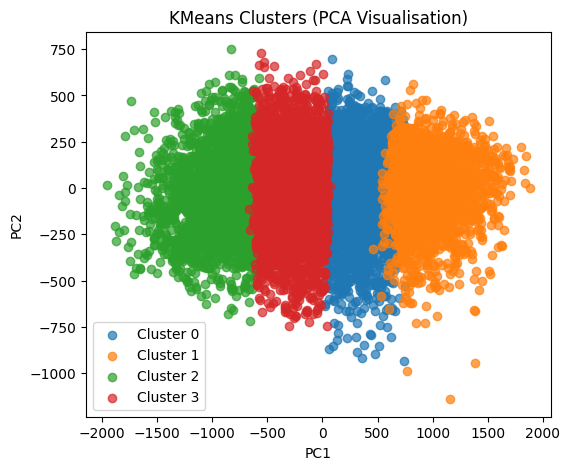

In [94]:
labels, df_km, model = run_kmeans_safe(X, df.index, n_clusters=4)

In [95]:
print("Labels:", labels)
print("\nCluster counts:\n", pd.Series(labels).value_counts())
print("\nModel inertia:", model.inertia_)
print("\nResult DF:\n", df_km.head())

Labels: [0 1 1 ... 0 0 0]

Cluster counts:
 0    4282
3    3973
2    2558
1    2018
Name: count, dtype: int64

Model inertia: 1932358536.4098632

Result DF:
       kmeans_label
file              
0                0
1                1
2                1
3                0
4                0


In [96]:
print("Cluster Centers:")
print(model.cluster_centers_)

Cluster Centers:
[[ 1.85034375e+03  1.19063676e+03  1.63035055e+03  4.46633880e+02
   2.09090222e+01  2.61419962e-02  3.50634841e+03  1.35637049e-01
   8.66074080e-02  1.55194491e+03  1.53454343e+02  3.99140640e+03
   1.19748714e+03  1.45512031e+00  1.38163623e+00  2.84603394e+01
   2.13834583e+00 -2.48033840e+02  1.15748637e+02  7.79467487e+01
   5.90200724e+01  6.34545561e+00  3.63662666e+01  3.26268747e+01
   3.04598685e+01 -7.30885822e+00  2.31064906e+01  3.43959880e+00
   1.71670351e+01 -1.17736391e+01  1.70262546e+01 -6.22587941e+00
   1.54456970e+01 -9.65334749e+00  1.39396648e+01 -6.44571211e-01
   1.29057695e+01 -1.04050980e+01  1.12146819e+01  1.14833334e+00
   1.00330501e+01 -7.37094450e+00  9.66239308e+00]
 [ 2.17181514e+03  1.19983650e+03  1.73748846e+03  3.96489866e+02
   2.08417150e+01  3.25965109e-02  4.05448801e+03  1.63820548e-01
   7.55655314e-02  1.72836907e+03  1.53491855e+02  3.99274804e+03
   1.22625270e+03  1.13035936e+00  4.45052485e-01  2.54283364e+01
   1.962

In [97]:
print("KMeans Inertia:", model.inertia_)

KMeans Inertia: 1932358536.4098632


In [98]:
print(df_km)

       kmeans_label
file               
0                 0
1                 1
2                 1
3                 0
4                 0
...             ...
12826             1
12827             0
12828             0
12829             0
12830             0

[12831 rows x 1 columns]


Silhouette Score: 0.27561968242315316


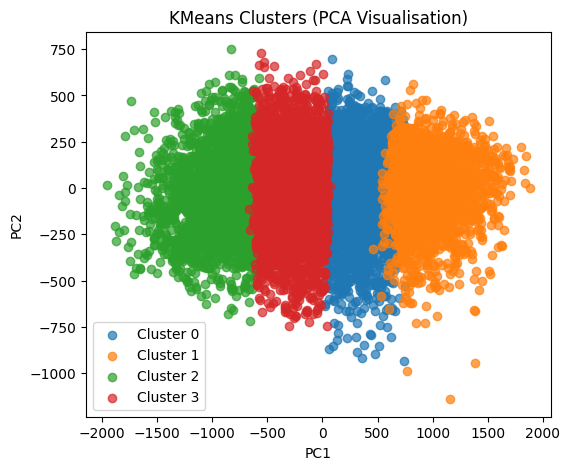


--- KMeans Output ---
Labels: [0 1 1 ... 0 0 0]

Cluster Centers:
 [[ 1.85034375e+03  1.19063676e+03  1.63035055e+03  4.46633880e+02
   2.09090222e+01  2.61419962e-02  3.50634841e+03  1.35637049e-01
   8.66074080e-02  1.55194491e+03  1.53454343e+02  3.99140640e+03
   1.19748714e+03  1.45512031e+00  1.38163623e+00  2.84603394e+01
   2.13834583e+00 -2.48033840e+02  1.15748637e+02  7.79467487e+01
   5.90200724e+01  6.34545561e+00  3.63662666e+01  3.26268747e+01
   3.04598685e+01 -7.30885822e+00  2.31064906e+01  3.43959880e+00
   1.71670351e+01 -1.17736391e+01  1.70262546e+01 -6.22587941e+00
   1.54456970e+01 -9.65334749e+00  1.39396648e+01 -6.44571211e-01
   1.29057695e+01 -1.04050980e+01  1.12146819e+01  1.14833334e+00
   1.00330501e+01 -7.37094450e+00  9.66239308e+00]
 [ 2.17181514e+03  1.19983650e+03  1.73748846e+03  3.96489866e+02
   2.08417150e+01  3.25965109e-02  4.05448801e+03  1.63820548e-01
   7.55655314e-02  1.72836907e+03  1.53491855e+02  3.99274804e+03
   1.22625270e+03  1.13

In [99]:
labels, df_km, model = run_kmeans_safe(X, df.index, n_clusters=4)
print("\n--- KMeans Output ---")
print("Labels:", labels)
print("\nCluster Centers:\n", model.cluster_centers_)
print("\nInertia:", model.inertia_)
print("\nFiles with assigned clusters:\n", df_km)

In [100]:
## DBSCAN FEATURE

In [101]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [102]:
def run_dbscan_safe(X, df_index, eps=None, min_samples=5, metric='euclidean', do_pca_plot=True):
    """
    Run DBSCAN with safety checks, optional automatic eps guess (k-distance),
    and PCA visualization. Returns: labels, result_df, dbscan_model
    """
    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError("X must be 2D")

    n_samples = X.shape[0]
    if n_samples == 0:
        raise ValueError("X has zero samples")

    # Fix NaN/Inf if any
    if np.isnan(X).any() or np.isinf(X).any():
        print("Imputing NaN/Inf with column means")
        col_mean = np.nanmean(np.where(np.isfinite(X), X, np.nan), axis=0)
        inds = np.where(~np.isfinite(X))
        X[inds] = np.take(col_mean, inds[1])

    # If eps not provided, estimate using k-distance (k = min_samples)
    if eps is None:
        k = max(1, min_samples)
        neigh = NearestNeighbors(n_neighbors=k, metric=metric)
        neigh.fit(X)
        distances, _ = neigh.kneighbors(X)
        kdist = np.sort(distances[:, -1])
        # Choose eps heuristic: elbow visually is best; here we pick 90th percentile as guess
        eps_guess = float(np.percentile(kdist, 90))
        print(f"Estimated eps (90th percentile of k-distance): {eps_guess:.6f}")
        # Also plot k-distance curve to help choose eps
        plt.figure(figsize=(6,3))
        plt.plot(kdist)
        plt.title(f"k-distance plot (k={k}) — inspect for elbow and pick eps")
        plt.xlabel("Points sorted by k-distance")
        plt.ylabel("k-distance")
        plt.show()
        eps = eps_guess

    # Run DBSCAN
    db = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
    labels = db.fit_predict(X)

    # Diagnostics
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"DBSCAN finished -> clusters: {n_clusters}, noise points: {n_noise}, eps={eps}, min_samples={min_samples}")

    # Result dataframe
    result_df = pd.DataFrame({'file': list(df_index), 'dbscan_label': labels}).set_index('file')

    # PCA visualization
    if do_pca_plot:
        try:
            pca = PCA(n_components=2)
            X2 = pca.fit_transform(X)
            plt.figure(figsize=(6,5))
            unique_labels = sorted(set(labels))
            for lbl in unique_labels:
                mask = labels == lbl
                if lbl == -1:
                    plt.scatter(X2[mask,0], X2[mask,1], marker='x', label='Noise (-1)', alpha=0.6)
                else:
                    plt.scatter(X2[mask,0], X2[mask,1], label=f'Cluster {lbl}', alpha=0.7)
            plt.legend()
            plt.title(f"DBSCAN clusters (eps={eps:.3f}, min_samples={min_samples})")
            plt.xlabel("PC1"); plt.ylabel("PC2")
            plt.show()
        except Exception as e:
            print("PCA/plot failed:", e)

    return labels, result_df, db

Estimated eps (90th percentile of k-distance): 163.784270


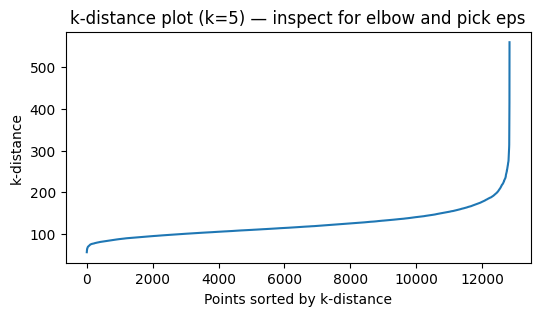

DBSCAN finished -> clusters: 5, noise points: 590, eps=163.78427014307593, min_samples=5


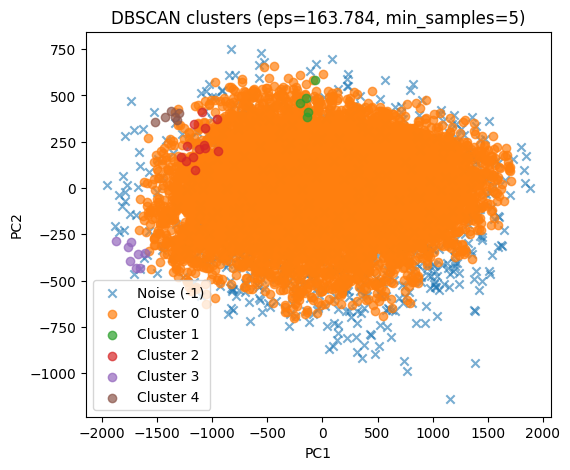

In [103]:
labels_db, df_db, db_model = run_dbscan_safe(X, df.index, eps=None, min_samples=5)

In [104]:
print("Labels:", labels_db)

Labels: [0 0 0 ... 0 0 0]


In [105]:
print("Cluster counts:\n", pd.Series(labels_db).value_counts())

Cluster counts:
  0    12209
-1      590
 2       13
 3        8
 4        6
 1        5
Name: count, dtype: int64


In [106]:
for lbl in sorted(df_db['dbscan_label'].unique()):
    print(f"\nLabel {lbl} (count={len(df_db[df_db['dbscan_label']==lbl])}):")
    print(df_db[df_db['dbscan_label']==lbl].index.tolist()[:20])


Label -1 (count=590):
[28, 35, 36, 53, 55, 56, 100, 104, 141, 143, 158, 159, 162, 185, 188, 189, 193, 206, 207, 208]

Label 0 (count=12209):
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

Label 1 (count=5):
[5178, 5253, 5550, 7357, 8773]

Label 2 (count=13):
[4645, 5333, 5592, 5749, 6097, 6378, 6530, 7026, 7738, 7939, 8916, 9507, 9599]

Label 3 (count=8):
[5582, 5863, 7195, 7451, 9033, 9245, 9866, 9926]

Label 4 (count=6):
[6149, 6259, 6758, 6818, 7067, 9411]


In [107]:
## Train Test Split (Random Forest, SVM, Neural Networks )

In [108]:
## Random Forest Regression

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report

In [110]:
if 'label' not in df.columns:
    raise SystemExit("label column missing unexpectedly.")

X = df.drop(columns=['label']).select_dtypes(include=[np.number]).copy()
if X.shape[1] == 0:
    raise SystemExit("No numeric features found to train on.")

y = df['label'].astype(int).copy()

In [111]:
print("Dataset shape:", df.shape)
print("Features used:", X.shape)
print("Label distribution:\n", y.value_counts())

Dataset shape: (12831, 44)
Features used: (12831, 43)
Label distribution:
 label
1    8542
0    4289
Name: count, dtype: int64


In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [113]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [114]:
regressor = RandomForestRegressor(n_estimators=10, random_state=0, oob_score=True)

regressor.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


RandomForestRegressor(n_estimators=10, oob_score=True, random_state=0)

In [115]:
regressor_pred = regressor.predict(X_test)

In [116]:
from sklearn.metrics import confusion_matrix

regressor_pred_binary = (regressor_pred >= 0.5).astype(int)

print("\n----- Random Forest -----")
print("Accuracy:", accuracy_score(y_test, regressor_pred_binary))
print(classification_report(y_test, regressor_pred_binary))
print("Confusion Matrix:\n", confusion_matrix(y_test, regressor_pred_binary))


----- Random Forest -----
Accuracy: 0.9984417608102844
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       858
           1       1.00      1.00      1.00      1709

    accuracy                           1.00      2567
   macro avg       1.00      1.00      1.00      2567
weighted avg       1.00      1.00      1.00      2567

Confusion Matrix:
 [[ 855    3]
 [   1 1708]]


In [117]:
## Support Vector Machine

In [118]:
from sklearn.svm import SVC

In [119]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
print("\n----- SVM -----")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))


----- SVM -----
Accuracy: 0.9996104402025711
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       858
           1       1.00      1.00      1.00      1709

    accuracy                           1.00      2567
   macro avg       1.00      1.00      1.00      2567
weighted avg       1.00      1.00      1.00      2567

Confusion Matrix:
 [[ 857    1]
 [   0 1709]]


In [120]:
## Neural Networks

In [121]:
from sklearn.neural_network import MLPClassifier

In [122]:
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=400, random_state=42)
mlp.fit(X_train_scaled, y_train)
mlp_pred = mlp.predict(X_test_scaled)
print("\n----- MLP -----")
print("Accuracy:", accuracy_score(y_test, mlp_pred))
print(classification_report(y_test, mlp_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, mlp_pred))


----- MLP -----
Accuracy: 0.9992208804051422
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       858
           1       1.00      1.00      1.00      1709

    accuracy                           1.00      2567
   macro avg       1.00      1.00      1.00      2567
weighted avg       1.00      1.00      1.00      2567

Confusion Matrix:
 [[ 857    1]
 [   1 1708]]


In [123]:
## Experiment with feature selection & Hyperparameter tuning

In [124]:
## 1. Feature Selection Experiments

In [125]:
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

In [126]:
selector_kbest = SelectKBest(score_func=f_classif, k=20)
selector_kbest.fit(X, y)

kbest_features = X.columns[selector_kbest.get_support()]
print("\n🔹 Top 20 Features (SelectKBest):")
print(kbest_features.tolist())


🔹 Top 20 Features (SelectKBest):
['mean_spectral_centroid', 'std_spectral_centroid', 'std_spectral_bandwidth', 'mean_spectral_contrast', 'mean_spectral_rolloff', 'zero_crossing_rate', 'rms_energy', 'min_pitch', 'log_energy', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_7_mean', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_12_mean', 'mfcc_12_std']


In [127]:
rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
top_rf = importances.sort_values(ascending=False).head(20)

print("\n🔹 Top 20 Features (RandomForest Importance):")
print(top_rf)


🔹 Top 20 Features (RandomForest Importance):
mfcc_5_mean               0.165028
mean_spectral_contrast    0.084203
mfcc_3_std                0.078558
std_spectral_bandwidth    0.073509
mfcc_2_mean               0.066351
mfcc_10_mean              0.038668
mfcc_4_mean               0.037597
rms_energy                0.036127
mfcc_10_std               0.035110
mfcc_6_mean               0.032042
mfcc_12_mean              0.029012
mfcc_1_mean               0.028678
mfcc_2_std                0.026347
mfcc_8_mean               0.019893
mfcc_13_mean              0.019210
mfcc_3_mean               0.017344
mfcc_7_mean               0.016267
mfcc_11_mean              0.015540
mfcc_6_std                0.014577
mfcc_5_std                0.013550
dtype: float64


In [128]:
## 2. Hyperparameter Tuning Experiments

### Model Evaluation and Comparison

In [131]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [132]:
def evaluate_classification(model, X_test, y_test):

  y_pred = model.predict(X_test)
  print("\n📈 Classification Metrics:")
  print(f" Accuracy: {accuracy_score(y_test, y_pred):.4f}")
  print(f" Precision: {precision_score(y_test, y_pred, average='binary'):.4f}")
  print(f" Recall: {recall_score(y_test, y_pred, average='binary'):.4f}")
  print(f" F1-Score: {f1_score(y_test, y_pred, average='binary'):.4f}")

In [134]:
y_pred = mlp_pred
print(f" Precision: {precision_score(y_test, y_pred, average='binary'):.4f}")
print(f" Recall: {recall_score(y_test, y_pred, average='binary'):.4f}")
print(f" F1-Score: {f1_score(y_test, y_pred, average='binary'):.4f}")

 Precision: 0.9994
 Recall: 0.9994
 F1-Score: 0.9994


In [135]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       858
           1       1.00      1.00      1.00      1709

    accuracy                           1.00      2567
   macro avg       1.00      1.00      1.00      2567
weighted avg       1.00      1.00      1.00      2567



In [136]:
## Clustering Evaluation Metrics (Silhouette Score)

In [137]:
from sklearn.metrics import silhouette_score

In [138]:
def evaluate_clustering(X, labels) :

  if len(set(labels)) < 2:
        print("❗ Silhouette score requires at least 2 clusters.")
        return

In [139]:
score = silhouette_score(X, labels)
print("\n🔹 Silhouette Score:", score)


🔹 Silhouette Score: 0.27561968242315316


## Classification

In [140]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [141]:
from sklearn.linear_model import LinearRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [142]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [143]:
from sklearn.svm import SVC

model = SVC(probability=True)
model.fit(X_train, y_train)

SVC(probability=True)

In [144]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

## Clustering

In [148]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=2)
clusters = model.fit_predict(X)

In [146]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.5, min_samples=5)
clusters = model.fit_predict(X)

In [147]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=2)
clusters = model.fit_predict(X)

In [150]:
df['cluster'] = clusters

print(pd.crosstab(df['label'], df['cluster']))

cluster     0     1
label              
0.0      2884  1405
1.0      3927  4615


In [151]:
import numpy as np

# Cluster → label mapping try
mapping = {0:1, 1:0}  # try reverse also

predicted = [mapping[c] for c in df['cluster']]
accuracy = np.mean(predicted == df['label'])

print("Clustering Accuracy:", accuracy)

Clustering Accuracy: 0.4155560751305432


In [152]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

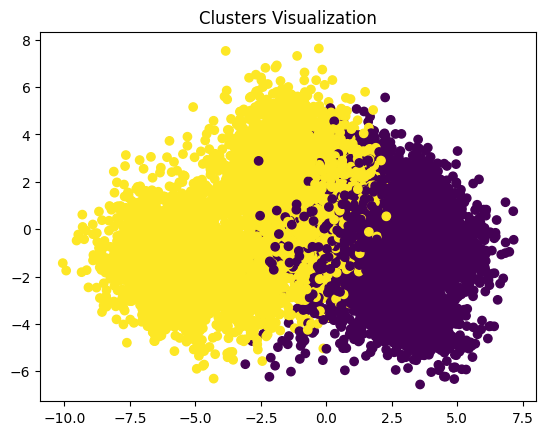

In [153]:
import matplotlib.pyplot as plt

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Clusters Visualization")
plt.show()